In [3]:
import os
from pathlib import Path
import json

import numpy as np
import matplotlib.pyplot as plt

In [4]:
TRAIN_RFENV_DIR = Path("./train_RFEnvs")

# Everything that will eventually constitute our final
# training artifacts goes here.
TRAIN_FINAL_DIR = Path("./train_final")

TRAIN_FINAL_DIR.mkdir(parents=True, exist_ok=True)

print("RF environments :", TRAIN_RFENV_DIR.resolve())
print("Final data       :", TRAIN_FINAL_DIR.resolve())

RF environments : C:\Users\vacha\OneDrive\Desktop\Programming\Python\Hackathons\SIH2026 - EW\train_RFEnvs
Final data       : C:\Users\vacha\OneDrive\Desktop\Programming\Python\Hackathons\SIH2026 - EW\train_final


In [5]:
# ============================================================
# RF ENVIRONMENT CONFIGURATION
# ============================================================

FREQ_MIN_MHZ = 0
FREQ_MAX_MHZ = 18_000

FREQ_BIN_MHZ = 500
TIME_BIN_S = 0.050

N_FREQ_BINS = int(
    (FREQ_MAX_MHZ - FREQ_MIN_MHZ) / FREQ_BIN_MHZ
)

FREQ_CENTRES_MHZ = np.arange(
    FREQ_MIN_MHZ + FREQ_BIN_MHZ / 2,
    FREQ_MAX_MHZ,
    FREQ_BIN_MHZ,
    dtype=np.float32
)

print("Frequency bands :", N_FREQ_BINS)
print("Frequency bin   :", FREQ_BIN_MHZ, "MHz")
print("Time bin        :", TIME_BIN_S * 1000, "ms")
print("Centres         :", FREQ_CENTRES_MHZ)

Frequency bands : 36
Frequency bin   : 500 MHz
Time bin        : 50.0 ms
Centres         : [  250.   750.  1250.  1750.  2250.  2750.  3250.  3750.  4250.  4750.
  5250.  5750.  6250.  6750.  7250.  7750.  8250.  8750.  9250.  9750.
 10250. 10750. 11250. 11750. 12250. 12750. 13250. 13750. 14250. 14750.
 15250. 15750. 16250. 16750. 17250. 17750.]


In [6]:
rf_files = sorted(
    p for p in TRAIN_RFENV_DIR.glob("*.npy")
    if p.name != "environment_config.npy"
)

if not rf_files:
    raise FileNotFoundError(
        f"No RF environment .npy files found in "
        f"{TRAIN_RFENV_DIR.resolve()}"
    )

print(f"Found {len(rf_files)} RF environments.")

Found 5 RF environments.


First we calculate the baseline probabiltiies P_b

In [7]:
# ============================================================
# CALCULATE BASELINE BAND PROBABILITIES
# ============================================================

def calculate_baseline_probabilities(rf_files):
    """
    Calculate baseline transmission probability for each
    frequency band across a collection of RF environments.

    Each RF environment contributes equally, regardless
    of its duration.

    Returns
    -------
    p_baseline : np.ndarray
        Shape: (N_FREQ_BINS,)
        Baseline probability for each frequency band.

    per_environment_probs : np.ndarray
        Shape: (N_environments, N_FREQ_BINS)
        Per-environment probabilities, useful for analysis.
    """

    per_environment_probs = []

    for path in rf_files:

        env = np.load(path)

        if env.ndim != 2:
            raise ValueError(
                f"{path.name} has shape {env.shape}; "
                "expected a 2D RF environment."
            )

        if env.shape[1] != N_FREQ_BINS:
            raise ValueError(
                f"{path.name} has {env.shape[1]} frequency bands; "
                f"expected {N_FREQ_BINS}."
            )

        # Fraction of time this band is active
        # within this particular scenario.
        band_probs = env.mean(axis=0)

        per_environment_probs.append(band_probs)

    per_environment_probs = np.asarray(
        per_environment_probs,
        dtype=np.float32
    )

    # Equal weight for every scenario.
    p_baseline = per_environment_probs.mean(axis=0)

    return p_baseline, per_environment_probs

In [8]:
P_baseline, per_environment_probs = (
    calculate_baseline_probabilities(rf_files)
)

print("P_baseline shape:", P_baseline.shape)

for band, (centre, prob) in enumerate(
    zip(FREQ_CENTRES_MHZ, P_baseline)
):
    print(
        f"Band {band:2d} | "
        f"Centre {centre:7.1f} MHz | "
        f"P = {prob:.4f}"
    )

P_baseline shape: (36,)
Band  0 | Centre   250.0 MHz | P = 0.0000
Band  1 | Centre   750.0 MHz | P = 0.0000
Band  2 | Centre  1250.0 MHz | P = 0.9139
Band  3 | Centre  1750.0 MHz | P = 0.2915
Band  4 | Centre  2250.0 MHz | P = 0.0204
Band  5 | Centre  2750.0 MHz | P = 0.7745
Band  6 | Centre  3250.0 MHz | P = 0.6699
Band  7 | Centre  3750.0 MHz | P = 0.5455
Band  8 | Centre  4250.0 MHz | P = 0.4107
Band  9 | Centre  4750.0 MHz | P = 0.4491
Band 10 | Centre  5250.0 MHz | P = 0.5754
Band 11 | Centre  5750.0 MHz | P = 0.6973
Band 12 | Centre  6250.0 MHz | P = 0.1708
Band 13 | Centre  6750.0 MHz | P = 0.0000
Band 14 | Centre  7250.0 MHz | P = 0.0000
Band 15 | Centre  7750.0 MHz | P = 0.0000
Band 16 | Centre  8250.0 MHz | P = 0.4004
Band 17 | Centre  8750.0 MHz | P = 0.6121
Band 18 | Centre  9250.0 MHz | P = 0.6801
Band 19 | Centre  9750.0 MHz | P = 0.3909
Band 20 | Centre 10250.0 MHz | P = 0.2371
Band 21 | Centre 10750.0 MHz | P = 0.2157
Band 22 | Centre 11250.0 MHz | P = 0.1208
Band 23 | 

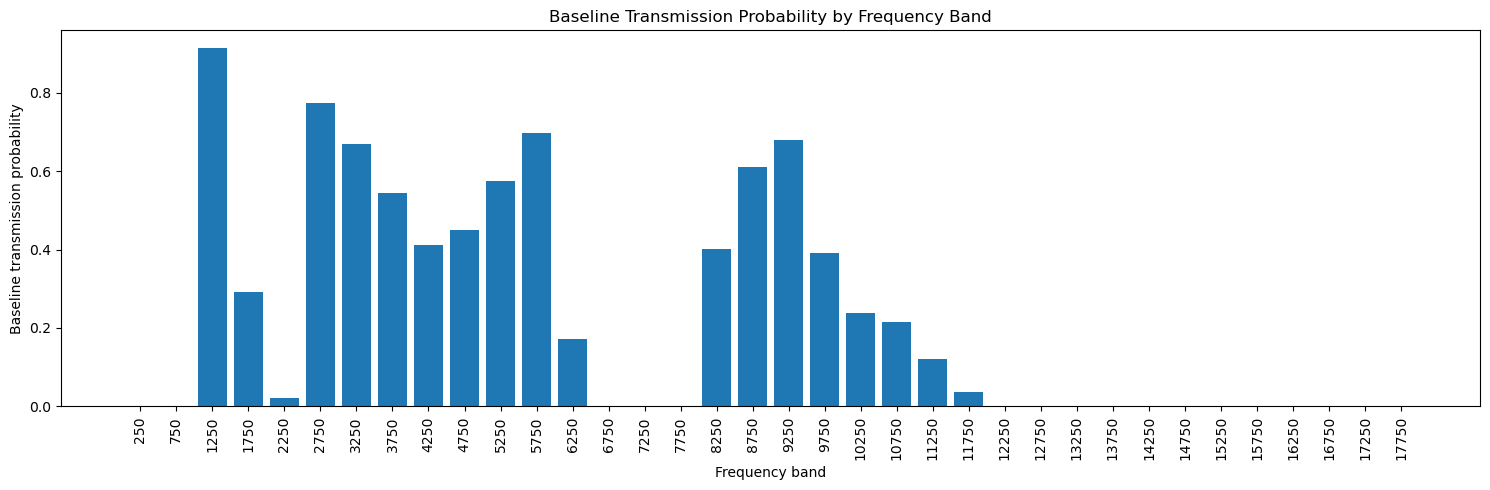

In [9]:
# ============================================================
# VISUALIZE BASELINE PROBABILITIES
# ============================================================

plt.figure(figsize=(15, 5))

plt.bar(
    np.arange(N_FREQ_BINS),
    P_baseline
)

plt.xlabel("Frequency band")
plt.ylabel("Baseline transmission probability")
plt.title("Baseline Transmission Probability by Frequency Band")

plt.xticks(
    np.arange(N_FREQ_BINS),
    [
        f"{int(freq)}"
        for freq in FREQ_CENTRES_MHZ
    ],
    rotation=90
)

plt.tight_layout()
plt.show()

In [10]:
# ============================================================
# SAVE P_BASELINE
# ============================================================

baseline_path = TRAIN_FINAL_DIR / "P_baseline.npy"

np.save(
    baseline_path,
    P_baseline.astype(np.float32)
)

print("Saved:", baseline_path)

Saved: train_final\P_baseline.npy


In [15]:
# ============================================================
# SAVE PER-ENVIRONMENT PROBABILITIES
# ============================================================

per_env_path = (
    TRAIN_FINAL_DIR /
    "P_baseline_per_environment.npy"
)

np.save(
    per_env_path,
    per_environment_probs.astype(np.float32)
)

print("Saved:", per_env_path)

Saved: train_final\P_baseline_per_environment.npy
